# Phase 1: Google Colab UNICEF Data Analysis
### Step 1: Data Upload
Upload the three CSV files (`unicef_indicator_1.csv`, `unicef_indicator_2.csv`, and `unicef_metadata.csv`) into your Google Colab workspace before running this notebook.

In [1]:
!pip install polars plotnine geopandas -q

import polars as pl
import numpy as np
from plotnine import *
import warnings
warnings.filterwarnings("ignore")

# Load data with Polars
literacy_df = pl.read_csv("unicef_indicator_1.csv", ignore_errors=True)
water_df    = pl.read_csv("unicef_indicator_2.csv", ignore_errors=True)
metadata_df = pl.read_csv("unicef_metadata.csv", ignore_errors=True)

print(f"Loaded: literacy={literacy_df.shape[0]}, water={water_df.shape[0]}, metadata={metadata_df.shape[0]} rows")

Loaded: literacy=273, water=3898, metadata=13715 rows


### Step 2: Data Cleaning & Pre-processing

In [2]:
# Clean and Prepare Data
for name in ["literacy_df", "water_df", "metadata_df"]:
    df = eval(name)
    new_cols = {c: c.strip().lower().replace(" ", "_") for c in df.columns}
    exec(f"{name} = df.rename(new_cols)")

obs_col = [c for c in literacy_df.columns if "obs_value" in c or "value" in c][0]
sex_col = [c for c in literacy_df.columns if "sex" in c][0]
country_col = [c for c in literacy_df.columns if "country" in c and "alpha" not in c][0]
alpha_col = [c for c in literacy_df.columns if "alpha_3" in c][0]
year_col = [c for c in literacy_df.columns if "time" in c or "year" in c][0]
w_obs = [c for c in water_df.columns if "obs_value" in c or "value" in c][0]
w_year_col = [c for c in water_df.columns if "time" in c or "year" in c][0]
m_year = [c for c in metadata_df.columns if "year" in c or "time" in c][0]
m_life = [c for c in metadata_df.columns if "life_expectancy" in c.lower() or "life" in c.lower()][0]
m_gdp = [c for c in metadata_df.columns if "gdp" in c.lower()][0]
m_pop = [c for c in metadata_df.columns if "pop" in c.lower()][0]
meta_alpha = [c for c in metadata_df.columns if "alpha_3" in c][0]

literacy_df = literacy_df.with_columns(pl.col(obs_col).cast(pl.Float64, strict=False).alias("obs_value"))
water_df = water_df.with_columns(pl.col(w_obs).cast(pl.Float64, strict=False).alias("obs_value"))

t_latest = literacy_df.filter(pl.col(sex_col).str.to_lowercase() == "total").sort(year_col).group_by(alpha_col).last()


### Step 3: Generate Individual Visualizations
The following blocks generate the plots sequentially and save them to `.png` files for Quarto to collate.

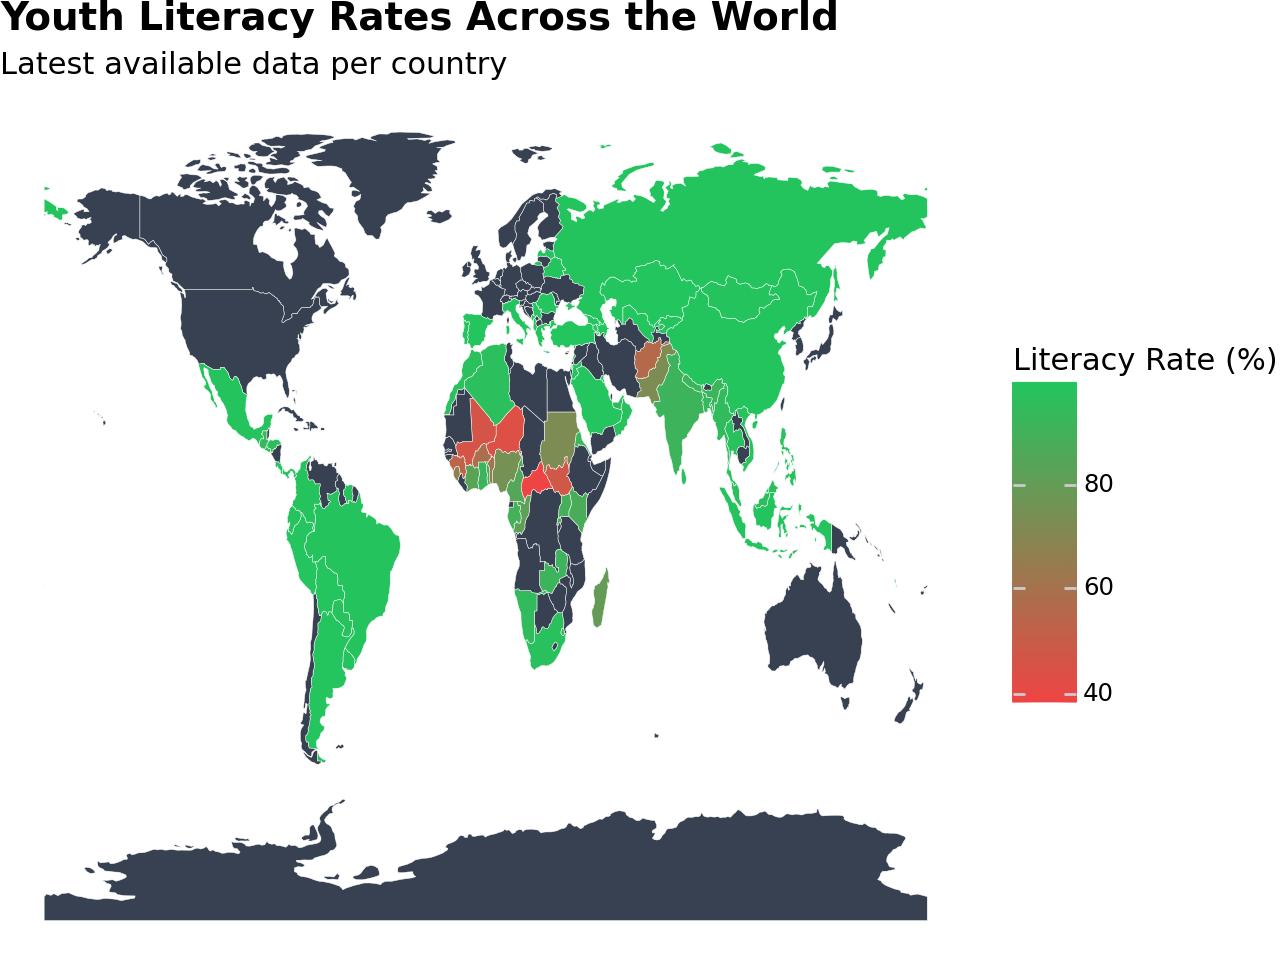

In [3]:
import geopandas as gpd
import math

world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")[["ISO_A3", "geometry", "NAME"]].rename(columns={"ISO_A3": "iso_a3"})
literacy_dict = dict(zip(t_latest[alpha_col].to_list(), t_latest["obs_value"].to_list()))
world["obs_value"] = [literacy_dict.get(code, math.nan) for code in world["iso_a3"]]

p1 = (
    ggplot(world)
    + geom_map(aes(fill="obs_value"), color="white", size=0.1)
    + scale_fill_gradient(low="#EF4444", high="#22C55E", na_value="#374151", name="Literacy Rate (%)")
    + labs(title="Youth Literacy Rates Across the World", subtitle="Latest available data per country")
    + theme_void()
    + theme(plot_title=element_text(size=14, weight="bold"))
)
p1.save("vis1_map.png", width=5, height=5, dpi=300)
p1

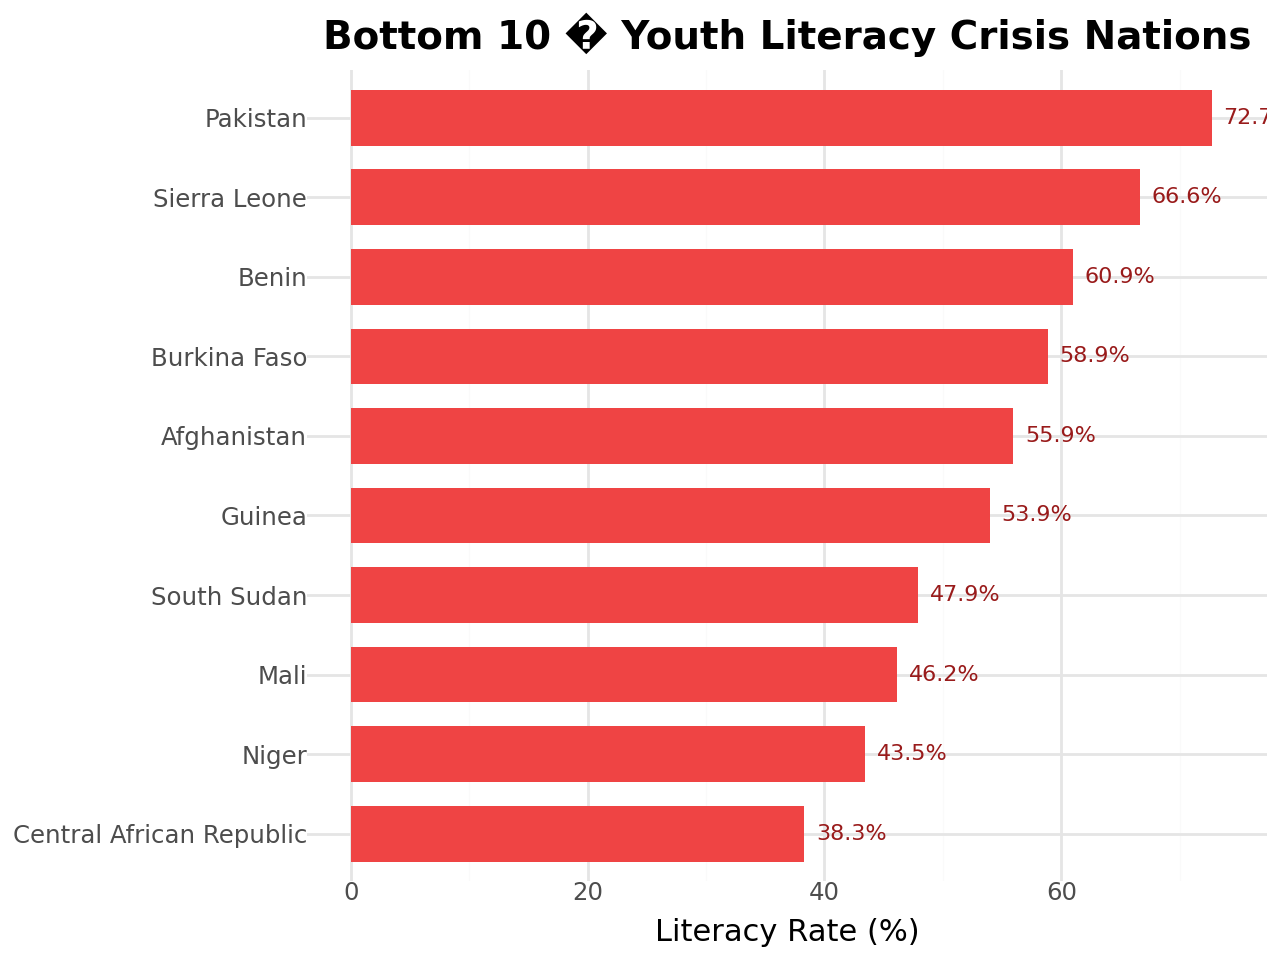

In [4]:
bottom10 = t_latest.sort("obs_value").head(10).with_columns(pl.col(country_col).cast(pl.Categorical).alias("country_cat"))
p2 = (
    ggplot(bottom10, aes(x=f"reorder({country_col}, obs_value)", y="obs_value"))
    + geom_bar(stat="identity", fill="#EF4444", width=0.7)
    + geom_text(aes(label="obs_value"), format_string="{:.1f}%", ha="left", nudge_y=1, size=8, color="#991B1B")
    + coord_flip()
    + labs(title="Bottom 10 � Youth Literacy Crisis Nations", x="", y="Literacy Rate (%)")
    + theme_minimal()
    + theme(plot_title=element_text(size=14, weight="bold"))
)
p2.save("vis2_bar.png", width=5, height=5, dpi=300)
p2

In [7]:
!pip install scikit-misc -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 4.3 MB/s eta 0:00:00


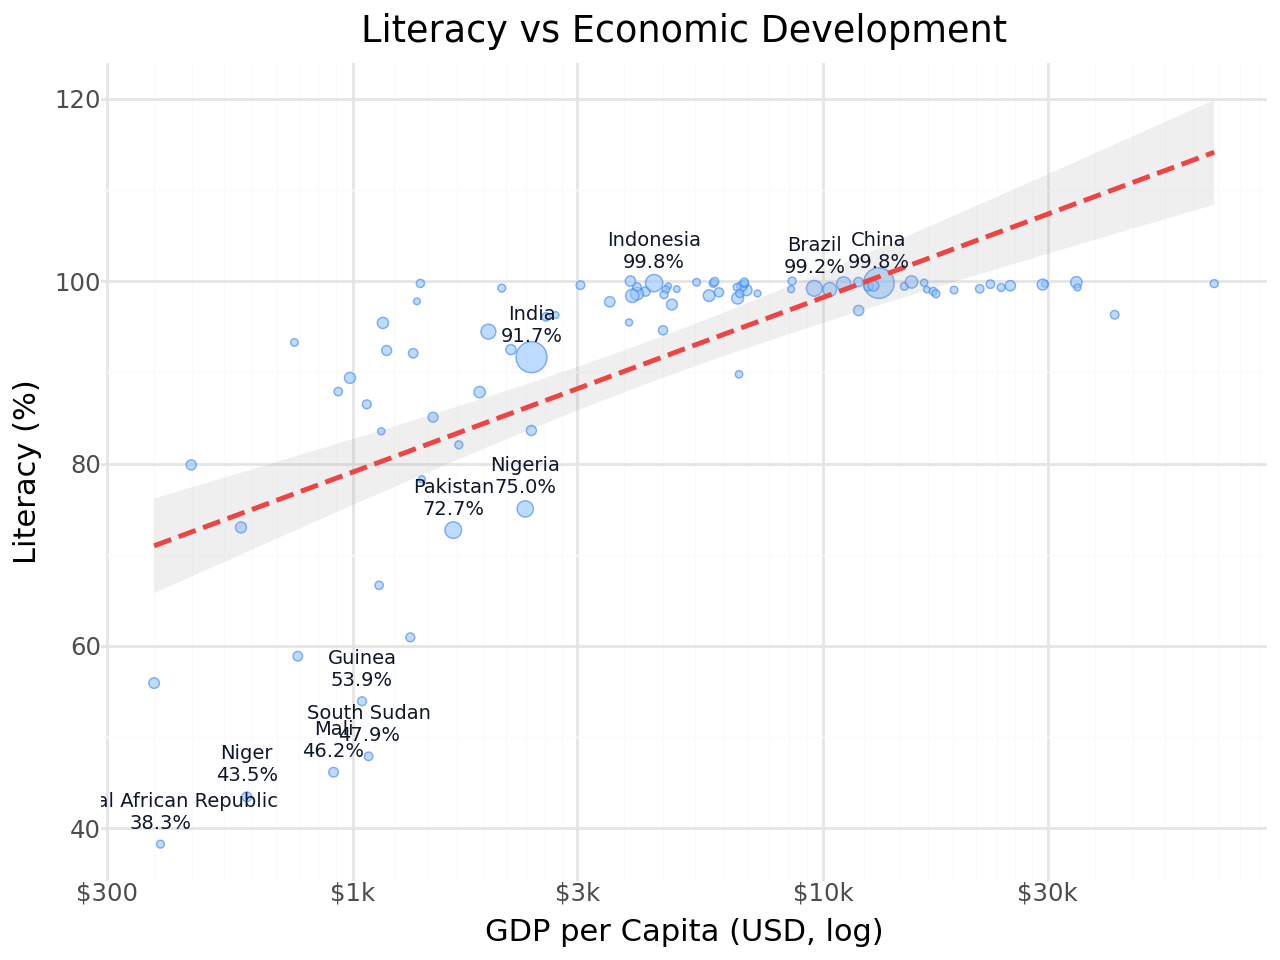

In [8]:
meta_clean = (metadata_df.with_columns([pl.col(m_year).cast(pl.Int64, strict=False), pl.col(m_gdp).cast(pl.Float64, strict=False), pl.col(m_pop).cast(pl.Float64, strict=False)]).drop_nulls(subset=[m_year, m_gdp, m_pop]).sort(m_year).group_by(meta_alpha).last().select([pl.col(meta_alpha).alias(alpha_col), pl.col(m_gdp), pl.col(m_pop)]))
scatter_df = t_latest.join(meta_clean, on=alpha_col, how="inner").drop_nulls(subset=["obs_value", m_gdp]).filter(pl.col(m_gdp) > 0)
scatter_df = scatter_df.with_columns(pl.struct([country_col, year_col, "obs_value", m_gdp, m_pop]).map_elements(lambda r: f"{r[country_col]}\n{r['obs_value']:.1f}%" if (r["obs_value"] < 55) or (r[m_gdp] > 70000) or (r[m_pop] > 2e8) else "", return_dtype=pl.Utf8).alias("label"))

p3 = (
    ggplot(scatter_df, aes(x=m_gdp, y="obs_value"))
    + geom_point(aes(size=m_pop), alpha=0.6, color="#3B82F6", fill="#93C5FD", stroke=0.3)
    + geom_smooth(method="lm", color="#EF4444", linetype="dashed", se=True, alpha=0.15)
    + geom_text(aes(label="label"), size=7, color="#0F172A", nudge_y=3.5)
    + scale_x_log10(labels=lambda lst: [f"${v/1000:.0f}k" if v >= 1000 else f"${v:.0f}" for v in lst])
    + labs(title="Literacy vs Economic Development", x="GDP per Capita (USD, log)", y="Literacy (%)")
    + theme_minimal()
    + theme(legend_position="none")
)
p3.save("vis3_scatter.png", width=5, height=5, dpi=300)
p3

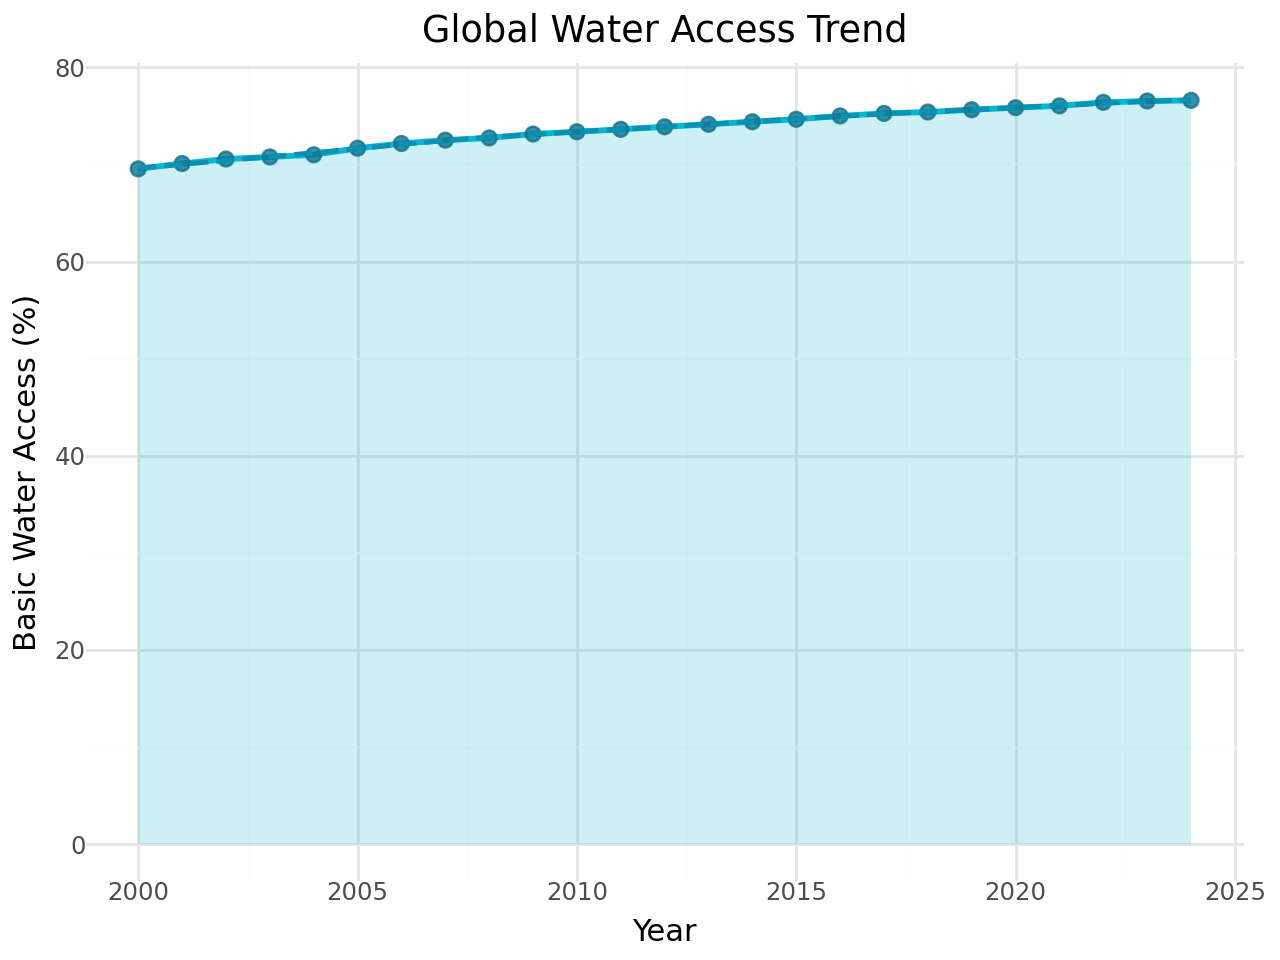

In [9]:
water_ts = water_df.with_columns(pl.col(w_year_col).cast(pl.Int64, strict=False).alias("year")).drop_nulls(subset=["year", "obs_value"]).group_by("year").agg(pl.col("obs_value").mean().alias("avg_water")).sort("year")

p4 = (
    ggplot(water_ts, aes(x="year", y="avg_water"))
    + geom_area(fill="#06B6D4", alpha=0.2)
    + geom_line(color="#06B6D4", size=1.2)
    + geom_point(color="#0E7490", size=2.5, alpha=0.8)
    + geom_smooth(method="loess", color="#0891B2", linetype="dashed", se=False, span=0.4)
    + labs(title="Global Water Access Trend", x="Year", y="Basic Water Access (%)")
    + theme_minimal()
)
p4.save("vis4_timeseries.png", width=5, height=5, dpi=300)
p4

In [10]:
!wget https://github.com/quarto-dev/quarto-cli/releases/download/v1.4.553/quarto-1.4.553-linux-amd64.deb -q
!dpkg -i quarto-1.4.553-linux-amd64.deb > /dev/null 2>&1
!quarto --version

1.4.553


In [14]:
!quarto render UNICEF_Polars_Report.qmd


Starting python3 kernel...Done

Executing 'UNICEF_Polars_Report.ipynb'
  Cell 1/11: 'setup'....................Done
  Cell 2/11: 'cleaning'.................Done
  Cell 3/11: 'summary'..................Done
  Cell 4/11: 'fig-world-map'............Done
  Cell 5/11: 'tbl-map-extremes'.........Done
  Cell 6/11: 'fig-bar-bottom10'.........Done
  Cell 7/11: 'tbl-bar-stories'..........Done
  Cell 8/11: 'fig-scatter-regression'...Done
  Cell 9/11: 'tbl-top15-gdp'............Done
  Cell 10/11: 'fig-timeseries-water'.....Done
  Cell 11/11: 'tbl-water-extremes'.......Done

pandoc 
  to: html
  output-file: UNICEF_Polars_Report.html
  standalone: true
  embed-resources: true
  section-divs: true
  html-math-method: mathjax
  wrap: none
  default-image-extension: png
  toc: true
  toc-depth: 3
  number-sections: true
  
metadata
  document-css: false
  link-citations: true
  date-format: long
  lang: en
  title: UNICEF Youth Literacy & Water Access Dashboard
  subtitle: Built with Polars & plotnin